# Harry Potter Question Answering System Using RAG

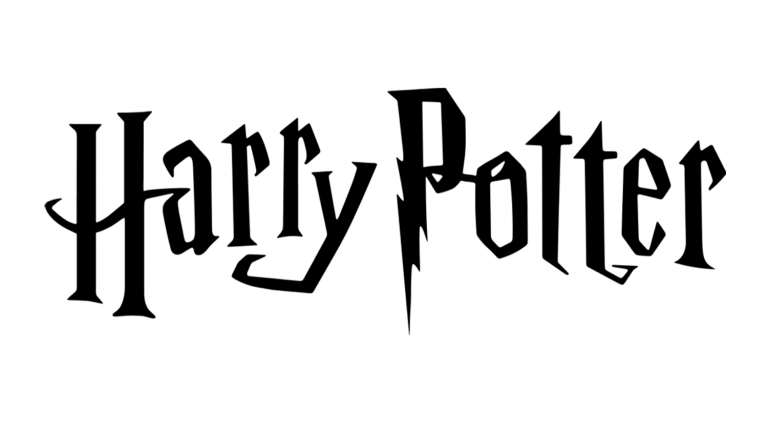

## 1. Introduction

### 1.1 Project Overview

This notebook implements a **Retrieval-Augmented Generation (RAG) system** for answering questions about the *Harry Potter* book series. The system uses the original Harry Potter books as its primary knowledge source, allowing users to ask questions in natural language and receive answers grounded in the content of the books.

Instead of relying only on the language model's pre-trained knowledge, the RAG pipeline retrieves the most relevant passages from the provided Harry Potter books and supplies them as context to the language model. This helps the system generate answers that are more **relevant, grounded, and traceable to the original source material**.

The complete pipeline follows these stages:

**Source PDF → Document Loading → Text Extraction → Chunking → Embeddings → Vector Store → Retrieval → Prompt Construction → Grounded Answer**

The source data consists of a **single PDF file containing the Harry Potter books**. During preprocessing, the PDF is divided into smaller text chunks while preserving important metadata such as page numbers and source information. These chunks are then converted into numerical vector representations using an embedding model and stored in a persistent vector database.

When a user submits a question, the system retrieves the most semantically relevant chunks from the vector store. The retrieved context is combined with the user's question and provided to the language model through a structured prompt. The model is instructed to answer **only using the retrieved book content** and to provide source information for the retrieved evidence.

### 1.2 Objectives


The main objectives of this notebook are to:

* Build a complete RAG pipeline using the original Harry Potter books as the knowledge base.
* Inspect and preprocess the source document before retrieval.
* Develop an appropriate chunking strategy for literary text.
* Generate embeddings for the extracted chunks.
* Store and persist the embeddings in a vector database.
* Implement semantic retrieval for user questions.
* Design a grounded prompt that combines retrieved context with the user's question.
* Evaluate the retrieval pipeline using representative Harry Potter questions.
* Provide citation-style source information indicating the document and page from which the retrieved information originated.


### 1.3 Expected System Behavior




Given a question such as:

> *Who gave Harry the Marauder's Map?*

the system should retrieve the relevant passages from the books and generate an answer based on those passages rather than producing an unsupported response from the language model's general knowledge.

The final response should also identify the source of the retrieved evidence, for example by referencing the **source document, book, page number, and/or chunk identifier**.

This approach makes the system more transparent and allows users to verify the information against the original books.

---


## 2. RAG Pipeline Development and Evaluation


The following sections implement and evaluate the main components of the Retrieval-Augmented Generation pipeline.


### 2.1 Load & Inspect

In [1]:
!pip install pymupdf qdrant_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 80.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 37.9 MB/s eta 0:00:00


#### Import and define the extraction function

In [2]:
import pymupdf


def pdf_to_markdown(pdf_path, markdown_path):
    """
    Extract text from a PDF page-by-page and save it as Markdown.

    Returns:
        pages_data: List containing page number and extracted text.
    """

    pages_data = []
    markdown = []

    with pymupdf.open(pdf_path) as pdf:

        for page_number, page in enumerate(pdf, start=1):

            text = page.get_text("text").strip()

            pages_data.append({
                "page": page_number,
                "text": text
            })

            markdown.append(f"## Page {page_number}\n\n")
            markdown.append(text)
            markdown.append("\n\n")

    with open(markdown_path, "w", encoding="utf-8") as file:
        file.write("".join(markdown))

    print(f"Markdown file created: {markdown_path}")

    return pages_data

#### Load the Harry Potter PDF

In [3]:
pdf_path = "data/harrypotter.pdf"
markdown_path = "data/output.md"


pages = pdf_to_markdown(pdf_path, markdown_path)

print(f"Total pages: {len(pages)}")

Markdown file created: data/output.md
Total pages: 3623


#### Inspect the extracted text

In [4]:
for page in pages[15:28]:
    print(f"--- Page {page['page']} ---")
    print(page["text"][:1000])
    print()

--- Page 16 ---
last report on the evening news:
“And finally, bird-watchers everywhere have reported that the nation’s
owls have been behaving very unusually today. Although owls normally hunt
at night and are hardly ever seen in daylight, there have been hundreds of
sightings of these birds flying in every direction since sunrise. Experts are
unable to explain why the owls have suddenly changed their sleeping
pattern.” The newscaster allowed himself a grin. “Most mysterious. And now,
over to Jim McGuffin with the weather. Going to be any more showers of
owls tonight, Jim?”
“Well, Ted,” said the weatherman, “I don’t know about that, but it’s not
only the owls that have been acting oddly today. Viewers as far apart as Kent,
Yorkshire, and Dundee have been phoning in to tell me that instead of the rain
I promised yesterday, they’ve had a downpour of shooting stars! Perhaps
people have been celebrating Bonfire Night early — it’s not until next week,
folks! But I can promise a wet night t

#### Check for empty and suspicious pages

In [5]:
empty_pages = []
low_text_pages = []

for page in pages:

    text_length = len(page["text"])

    if text_length == 0:
        empty_pages.append(page["page"])

    elif text_length < 100:
        low_text_pages.append(page["page"])


print(f"Empty pages: {len(empty_pages)}")
print(f"Empty page numbers: {empty_pages}")

print(f"\nLow-text pages: {len(low_text_pages)}")
print(f"Low-text page numbers: {low_text_pages}")

Empty pages: 19
Empty page numbers: [1, 2, 3, 4, 5, 7, 8, 276, 277, 567, 568, 941, 942, 1562, 1563, 2408, 2409, 2966, 2967]

Low-text pages: 17
Low-text page numbers: [9, 278, 281, 352, 569, 784, 1209, 1564, 1684, 2117, 2357, 2410, 2708, 2865, 2975, 3009, 3616]


#### Basic Statistics

In [6]:
total_characters = sum(len(page["text"]) for page in pages)
total_words = sum(len(page["text"].split()) for page in pages)

print(f"Total pages: {len(pages):,}")
print(f"Total characters: {total_characters:,}")
print(f"Total words: {total_words:,}")
print(f"Empty pages: {len(empty_pages)}")
print(f"Low-text pages: {len(low_text_pages)}")

Total pages: 3,623
Total characters: 6,273,981
Total words: 1,121,939
Empty pages: 19
Low-text pages: 17


#### Inspection Results



The source dataset consists of a single PDF file, `harrypotter.pdf`, containing the Harry Potter book collection.

The PDF contains **3,623 pages**. Using PyMuPDF, the document was processed page-by-page and the extracted text was preserved together with its corresponding page number. This page-level metadata will be used later to support source tracking and citation-style grounding.

The extraction process produced the following results:

* **Total pages:** 3,623
* **Total extracted characters:** 6,273,981
* **Total extracted words:** 1,121,939
* **Empty pages:** 19
* **Low-text pages:** 17
* **Source format:** PDF

The majority of the document contains successfully extractable text and is suitable for the next preprocessing stage.

The **19 empty pages** and **17 low-text pages** were flagged for further inspection. These pages may correspond to blank pages, title pages, formatting pages, or image-based content. Therefore, they are not automatically considered parsing failures or OCR requirements. OCR will only be considered if manual inspection confirms that meaningful book content is present but could not be extracted as text.

The extracted content was also saved as `output.md`, providing an intermediate Markdown representation of the source document. Preserving the page numbers at this stage will allow the RAG pipeline to associate retrieved chunks with their original source pages.


### 2.2 Semantic Chunking Strategy



A semantic chunking strategy is used to divide the Harry Potter books into meaningful retrieval units. Unlike fixed-size chunking, which splits the text based only on a predefined number of characters or tokens, semantic chunking considers the meaning and contextual relationship between consecutive sentences.

The extracted text is first cleaned and divided into sentence-level units while preserving the original page number of every sentence. Sentence embeddings are then generated using the `all-MiniLM-L6-v2` model. The cosine similarity between consecutive sentences is used to identify semantic transitions. A significant decrease in similarity indicates a potential change in topic, event, or narrative context and can therefore be used as a chunk boundary.

To maintain practical chunk sizes, semantic boundaries are combined with token-based constraints. Each chunk has a target range of approximately **200–500 tokens**. This prevents the creation of extremely small chunks while also preventing excessively large chunks that could reduce retrieval precision.

The semantic threshold is determined dynamically from the similarity distribution of each book rather than using a single manually selected threshold for the entire dataset. This makes the strategy more adaptive to differences in writing style and content throughout the seven books.

The following metadata is preserved for every chunk:

* Book title
* Starting page
* Ending page
* Unique chunk ID
* Token count

Although semantic chunking requires additional computation because sentence embeddings must be generated during preprocessing, this approach is suitable for Google Colab and is expected to provide more semantically coherent retrieval contexts for the Harry Potter question-answering system.


In [7]:
# ============================================================
# 2.2 SEMANTIC CHUNKING
# Harry Potter RAG Pipeline
# ============================================================

# Install required libraries
!pip install -q sentence-transformers scikit-learn tiktoken nltk

In [8]:
# ============================================================
# Imports
# ============================================================

import re
import json
import numpy as np

from pathlib import Path
from collections import defaultdict

import tiktoken
import nltk

from nltk.tokenize import sent_tokenize
from sentence_transformers import SentenceTransformer

In [9]:
# Download NLTK sentence tokenizer
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [10]:
# ============================================================
# Configuration
# ============================================================

INPUT_FILE = Path("data/output.md")

OUTPUT_FOLDER = Path("dataset_chunks")
OUTPUT_FILE = OUTPUT_FOLDER / "harry_potter_chunks.json"

# Semantic chunk constraints
MIN_TOKENS = 200
MAX_TOKENS = 500

# Percentage of lowest similarities used to determine
# semantic boundaries
SIMILARITY_PERCENTILE = 15

# Sentence embedding model
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

# Tokenizer used for measuring chunk size
TOKENIZER_NAME = "cl100k_base"

encoding = tiktoken.get_encoding(TOKENIZER_NAME)

In [11]:
# ============================================================
# Book page ranges
# ============================================================

BOOK_RANGES = [
    ("Harry Potter and the Sorcerer Stone", 12, 274),
    ("Harry Potter and the Chamber of Secrets", 282, 565),
    ("Harry Potter and the Prisoner of Azkaban", 573, 939),
    ("Harry Potter and the Goblet of Fire", 949, 1560),
    ("Harry Potter and the Order of the Phoenix", 1570, 2406),
    ("Harry Potter and the Half-Blood Prince", 2409, 2964),
    ("Harry Potter and the Deathly Hallows", 2974, 3622),
]


def get_book_name(page_number):
    """
    Return the book name corresponding to a PDF page number.
    """

    for book_name, first_page, last_page in BOOK_RANGES:

        if first_page <= page_number <= last_page:
            return book_name

    return None

In [12]:
# ============================================================
# Text cleaning
# ============================================================

def clean_text(text):
    """
    Clean extracted text by removing extra whitespace.
    """

    text = re.sub(r'\s+', ' ', text)
    text = text.replace(r'[\r\n]+', '\n').strip()

    return text.strip()

In [13]:
# ============================================================
# Extract pages from output.md
# ============================================================

def extract_pages():
    """
    Extract pages from the Markdown representation of the PDF.

    Each page is stored with:
        - page number
        - book name
        - cleaned text
    """

    text = INPUT_FILE.read_text(
        encoding="utf-8"
    )

    pages = re.split(
        r"^##\s*Page\s+(\d+)\s*$",
        text,
        flags=re.MULTILINE
    )

    page_data = []

    for i in range(1, len(pages), 2):

        page_number = int(pages[i])

        page_content = clean_text(
            pages[i + 1]
        )

        book_name = get_book_name(
            page_number
        )

        # Ignore pages that have no book mapping
        # or contain no extracted text.
        if book_name and page_content:

            page_data.append({
                "page": page_number,
                "book": book_name,
                "text": page_content
            })

    return page_data

In [14]:
# Load pages

pages = extract_pages()

print(f"Valid pages loaded: {len(pages):,}")

Valid pages loaded: 3,567


In [15]:
# ============================================================
# Sentence segmentation
# ============================================================

def split_into_sentences(text):
    """
    Split cleaned text into sentence-level units.
    """

    sentences = sent_tokenize(text)

    return [
        sentence.strip()
        for sentence in sentences
        if sentence.strip()
    ]

In [16]:
# ============================================================
# Load sentence embedding model
# ============================================================

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print(
    f"Embedding model loaded: "
    f"{EMBEDDING_MODEL_NAME}"
)

print(
    f"Device: {embedding_model.device}"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded: all-MiniLM-L6-v2
Device: cuda:0


In [17]:
# ============================================================
# Create semantic chunks for one book
# ============================================================

def create_book_semantic_chunks(
    book_name,
    book_pages,
    starting_chunk_id
):
    """
    Create semantically coherent chunks for one book.

    The process:
        1. Convert pages into sentence-level units.
        2. Preserve page metadata for every sentence.
        3. Generate sentence embeddings.
        4. Calculate similarity between consecutive sentences.
        5. Detect semantic boundaries dynamically.
        6. Respect minimum and maximum token constraints.
    """

    # --------------------------------------------------------
    # 1. Sort pages
    # --------------------------------------------------------

    book_pages = sorted(
        book_pages,
        key=lambda x: x["page"]
    )

    # --------------------------------------------------------
    # 2. Create sentence units
    # --------------------------------------------------------

    sentence_units = []

    for page in book_pages:

        sentences = split_into_sentences(
            page["text"]
        )

        for sentence in sentences:

            sentence_units.append({
                "text": sentence,
                "page": page["page"]
            })

    if not sentence_units:
        return [], starting_chunk_id

    # --------------------------------------------------------
    # 3. Extract sentence texts
    # --------------------------------------------------------

    sentences = [
        unit["text"]
        for unit in sentence_units
    ]

    # --------------------------------------------------------
    # 4. Generate sentence embeddings
    # --------------------------------------------------------

    sentence_embeddings = embedding_model.encode(
        sentences,
        batch_size=64,
        show_progress_bar=True,
        normalize_embeddings=True
    )

    sentence_embeddings = np.asarray(
        sentence_embeddings
    )

    # --------------------------------------------------------
    # 5. Calculate similarity between consecutive sentences
    # --------------------------------------------------------

    similarities = []

    for i in range(
        len(sentence_embeddings) - 1
    ):

        similarity = np.dot(
            sentence_embeddings[i],
            sentence_embeddings[i + 1]
        )

        similarities.append(
            float(similarity)
        )

    # --------------------------------------------------------
    # 6. Determine dynamic semantic threshold
    # --------------------------------------------------------

    if similarities:

        threshold = np.percentile(
            similarities,
            SIMILARITY_PERCENTILE
        )

    else:

        threshold = 0.0

    print(
        f"\nBook: {book_name}"
    )

    print(
        f"Sentences: {len(sentences):,}"
    )

    print(
        f"Semantic threshold: {threshold:.4f}"
    )

    # --------------------------------------------------------
    # 7. Build chunks
    # --------------------------------------------------------

    book_chunks = []

    current_units = []
    current_tokens = 0

    chunk_id = starting_chunk_id

    for i, unit in enumerate(sentence_units):

        sentence = unit["text"]

        sentence_tokens = len(
            encoding.encode(sentence)
        )

        # ----------------------------------------------------
        # Handle sentences larger than MAX_TOKENS
        # ----------------------------------------------------

        if sentence_tokens > MAX_TOKENS:

            # Save current chunk first
            if current_units:

                book_chunks.append(
                    create_chunk_record(
                        current_units,
                        book_name,
                        chunk_id
                    )
                )

                chunk_id += 1

                current_units = []
                current_tokens = 0

            # Split very large sentence at token level
            sentence_token_ids = encoding.encode(
                sentence
            )

            start = 0

            while start < len(sentence_token_ids):

                end = min(
                    start + MAX_TOKENS,
                    len(sentence_token_ids)
                )

                token_ids = sentence_token_ids[
                    start:end
                ]

                split_text = encoding.decode(
                    token_ids
                )

                book_chunks.append({

                    "chunk_id": (
                        f"chunk_{chunk_id:05d}"
                    ),

                    "book": book_name,

                    "page_start": unit["page"],

                    "page_end": unit["page"],

                    "text": split_text,

                    "token_count": len(token_ids)

                })

                chunk_id += 1

                start = end

            continue

        # ----------------------------------------------------
        # First sentence
        # ----------------------------------------------------

        if not current_units:

            current_units.append(unit)

            current_tokens = sentence_tokens

            continue

        # ----------------------------------------------------
        # Semantic similarity with previous sentence
        # ----------------------------------------------------

        similarity = similarities[i - 1]

        semantic_break = (
            similarity < threshold
            and current_tokens >= MIN_TOKENS
        )

        size_break = (
            current_tokens + sentence_tokens
            > MAX_TOKENS
        )

        # ----------------------------------------------------
        # Create new chunk
        # ----------------------------------------------------

        if semantic_break or size_break:

            book_chunks.append(
                create_chunk_record(
                    current_units,
                    book_name,
                    chunk_id
                )
            )

            chunk_id += 1

            current_units = [unit]

            current_tokens = sentence_tokens

        else:

            current_units.append(unit)

            current_tokens += sentence_tokens

    # --------------------------------------------------------
    # 8. Save final chunk
    # --------------------------------------------------------

    if current_units:

        book_chunks.append(
            create_chunk_record(
                current_units,
                book_name,
                chunk_id
            )
        )

        chunk_id += 1

    return book_chunks, chunk_id

In [18]:
# ============================================================
# Chunk metadata creator
# ============================================================

def create_chunk_record(
    units,
    book_name,
    chunk_id
):
    """
    Create a chunk dictionary with source metadata.
    """

    chunk_text = " ".join(
        unit["text"]
        for unit in units
    )

    pages = [
        unit["page"]
        for unit in units
    ]

    token_count = len(
        encoding.encode(chunk_text)
    )

    return {

        "chunk_id": (
            f"chunk_{chunk_id:05d}"
        ),

        "book": book_name,

        "page_start": min(pages),

        "page_end": max(pages),

        "text": chunk_text,

        "token_count": token_count
    }

In [19]:
# ============================================================
# Group pages by book
# ============================================================

books = defaultdict(list)

for page in pages:

    books[page["book"]].append(page)


print(
    f"Books detected: {len(books)}"
)

for book_name, book_pages in books.items():

    print(
        f"{book_name}: "
        f"{len(book_pages):,} pages"
    )

Books detected: 7
Harry Potter and the Sorcerer Stone: 263 pages
Harry Potter and the Chamber of Secrets: 284 pages
Harry Potter and the Prisoner of Azkaban: 367 pages
Harry Potter and the Goblet of Fire: 612 pages
Harry Potter and the Order of the Phoenix: 837 pages
Harry Potter and the Half-Blood Prince: 555 pages
Harry Potter and the Deathly Hallows: 649 pages


In [20]:
# ============================================================
# Create semantic chunks for all books
# ============================================================

all_chunks = []

next_chunk_id = 1

for book_name, book_pages in books.items():

    book_chunks, next_chunk_id = (
        create_book_semantic_chunks(
            book_name,
            book_pages,
            next_chunk_id
        )
    )

    all_chunks.extend(
        book_chunks
    )


print("\n" + "=" * 70)

print(
    f"Total semantic chunks: "
    f"{len(all_chunks):,}"
)

Batches:   0%|          | 0/92 [00:00<?, ?it/s]


Book: Harry Potter and the Sorcerer Stone
Sentences: 5,873
Semantic threshold: 0.1437


Batches:   0%|          | 0/103 [00:00<?, ?it/s]


Book: Harry Potter and the Chamber of Secrets
Sentences: 6,546
Semantic threshold: 0.1457


Batches:   0%|          | 0/153 [00:00<?, ?it/s]

...


Book: Harry Potter and the Order of the Phoenix
Sentences: 19,656
Semantic threshold: 0.1326


Batches:   0%|          | 0/200 [00:00<?, ?it/s]


Book: Harry Potter and the Half-Blood Prince
Sentences: 12,744
Semantic threshold: 0.1316


Batches:   0%|          | 0/218 [00:00<?, ?it/s]


Book: Harry Potter and the Deathly Hallows
Sentences: 13,926
Semantic threshold: 0.1323

Total semantic chunks: 4,430


In [21]:
# ============================================================
# Inspect first 3 chunks
# ============================================================

for chunk in all_chunks[:3]:

    print("=" * 80)

    print(
        f"Chunk ID: {chunk['chunk_id']}"
    )

    print(
        f"Book: {chunk['book']}"
    )

    print(
        f"Pages: "
        f"{chunk['page_start']} - "
        f"{chunk['page_end']}"
    )

    print(
        f"Tokens: "
        f"{chunk['token_count']}"
    )

    print("\nText:")
    print(
        chunk["text"][:1500]
    )

    print()

Chunk ID: chunk_00001
Book: Harry Potter and the Sorcerer Stone
Pages: 12 - 13
Tokens: 458

Text:
M CHAPTER ONE THE BOY WHO LIVED r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense. Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. The Dursleys had a small son called Dudley and in their opinion there was no finer boy anywhere. The Dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would discover it. They didn’t think they 

In [22]:
# ============================================================
# Chunk statistics
# ============================================================

token_counts = [
    chunk["token_count"]
    for chunk in all_chunks
]

print(
    f"Total chunks: "
    f"{len(all_chunks):,}"
)

print(
    f"Average tokens per chunk: "
    f"{np.mean(token_counts):.2f}"
)

print(
    f"Median tokens per chunk: "
    f"{np.median(token_counts):.2f}"
)

print(
    f"Minimum tokens: "
    f"{np.min(token_counts)}"
)

print(
    f"Maximum tokens: "
    f"{np.max(token_counts)}"
)

Total chunks: 4,430
Average tokens per chunk: 336.96
Median tokens per chunk: 313.00
Minimum tokens: 18
Maximum tokens: 512


In [23]:
# ============================================================
# Chunk size validation
# ============================================================

too_small = [
    chunk
    for chunk in all_chunks
    if chunk["token_count"] < MIN_TOKENS
]

too_large = [
    chunk
    for chunk in all_chunks
    if chunk["token_count"] > MAX_TOKENS
]

print(
    f"Chunks below minimum size: "
    f"{len(too_small):,}"
)

print(
    f"Chunks above maximum size: "
    f"{len(too_large):,}"
)

Chunks below minimum size: 19
Chunks above maximum size: 143


In [24]:
# ============================================================
# Check chunks spanning multiple pages
# ============================================================

multi_page_chunks = [
    chunk
    for chunk in all_chunks
    if chunk["page_end"] > chunk["page_start"]
]

print(
    f"Chunks spanning multiple pages: "
    f"{len(multi_page_chunks):,}"
)

for chunk in multi_page_chunks[:3]:

    print("=" * 80)

    print(
        f"{chunk['book']} | "
        f"Pages {chunk['page_start']}-"
        f"{chunk['page_end']}"
    )

    print(
        chunk["text"][:800]
    )

Chunks spanning multiple pages: 3,099
Harry Potter and the Sorcerer Stone | Pages 12-13
M CHAPTER ONE THE BOY WHO LIVED r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense. Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. The Dursleys had a small son called Dudley and in their opinion there was no finer boy anywhere. The Dursleys had everything they wanted, but they a
Harry Potter and the Sorcerer Stone | Pages 13-14
Mr. Dursley was enraged to see that a couple of them weren’t 

In [25]:
# ============================================================
# Save chunks as JSON
# ============================================================

OUTPUT_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

with open(
    OUTPUT_FILE,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        all_chunks,
        file,
        ensure_ascii=False,
        indent=2
    )

print(
    f"Semantic chunks saved to:\n"
    f"{OUTPUT_FILE}"
)

Semantic chunks saved to:
dataset_chunks/harry_potter_chunks.json


### 2.3 Embeddings & Vector Store


The semantically generated chunks are converted into dense vector representations using the `intfloat/multilingual-e5-large` embedding model. This model was selected because it provides strong semantic representation capabilities and supports multilingual text, which makes it suitable for a retrieval-based question-answering system.

Each chunk is prefixed with `passage:` before generating its embedding, following the recommended input format for the E5 embedding model.

The resulting embeddings are stored in a **Qdrant vector database** using cosine similarity. Each vector is associated with its original chunk metadata, including the book title, page range, chunk ID, token count, and text content. This metadata allows the retrieval system to return both relevant context and its original source information for citation-style grounding.

The Qdrant collection is created only if it does not already exist. Chunks are uploaded in batches to avoid unnecessary memory and request overhead.

The vector database is persistent and can be accessed by the RAG backend without regenerating the embeddings, allowing the retrieval pipeline to load the existing knowledge base directly.


In [26]:
from pathlib import Path
import json
import os

from sentence_transformers import SentenceTransformer

from qdrant_client import QdrantClient, models
from dotenv import load_dotenv

In [27]:
# ============================================================
# Load semantic chunks
# ============================================================

CHUNKS_FILE = Path(
    "dataset_chunks/harry_potter_chunks.json"
)

with open(
    CHUNKS_FILE,
    "r",
    encoding="utf-8"
) as file:

    chunks = json.load(file)

print(
    f"Loaded {len(chunks):,} semantic chunks."
)

Loaded 4,430 semantic chunks.


In [28]:
print(json.dumps(
    chunks[0],
    indent=2,
    ensure_ascii=False
))

{
  "chunk_id": "chunk_00001",
  "book": "Harry Potter and the Sorcerer Stone",
  "page_start": 12,
  "page_end": 13,
  "text": "M CHAPTER ONE THE BOY WHO LIVED r. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you very much. They were the last people you’d expect to be involved in anything strange or mysterious, because they just didn’t hold with such nonsense. Mr. Dursley was the director of a firm called Grunnings, which made drills. He was a big, beefy man with hardly any neck, although he did have a very large mustache. Mrs. Dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. The Dursleys had a small son called Dudley and in their opinion there was no finer boy anywhere. The Dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would disco

In [29]:
texts = [
    f"passage: {chunk['text']}"
    for chunk in chunks
]

In [30]:
MODEL_NAME = "intfloat/multilingual-e5-large"

model = SentenceTransformer(
    MODEL_NAME
)

print(
    f"Loaded embedding model: {MODEL_NAME}"
)

print(
    f"Embedding dimension: "
    f"{model.get_sentence_embedding_dimension()}"
)

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.24GB            

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Loaded embedding model: intfloat/multilingual-e5-large
Embedding dimension: 1024


/tmp/ipykernel_2189/3958219218.py:13: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  f"{model.get_sentence_embedding_dimension()}"


In [31]:
embeddings = model.encode(
    texts,
    batch_size=32,
    normalize_embeddings=True,
    show_progress_bar=True,
)

Batches:   0%|          | 0/139 [00:00<?, ?it/s]

In [32]:
print(
    f"Number of embeddings: {len(embeddings):,}"
)

print(
    f"Embedding dimension: {len(embeddings[0])}"
)

Number of embeddings: 4,430
Embedding dimension: 1024


In [33]:
# ============================================================
# Qdrant configuration
# ============================================================

load_dotenv()

QDRANT_URL = os.getenv("QDRANT_URL")
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
QDRANT_COLLECTION = os.getenv(
    "QDRANT_COLLECTION"
)

In [34]:
client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY,
)

print("Connected to Qdrant.")

Connected to Qdrant.


In [35]:
vector_size = len(
    embeddings[0]
)

if not client.collection_exists(
    QDRANT_COLLECTION
):

    client.create_collection(

        collection_name=QDRANT_COLLECTION,

        vectors_config=models.VectorParams(

            size=vector_size,

            distance=models.Distance.COSINE
        )
    )

    print(
        f"Created collection: "
        f"{QDRANT_COLLECTION}"
    )

else:

    print(
        f"Collection already exists: "
        f"{QDRANT_COLLECTION}"
    )

Created collection: harrypotter_final_RAG_project


In [36]:
points = []

for index, (
    chunk,
    embedding
) in enumerate(
    zip(chunks, embeddings)
):

    points.append(
        models.PointStruct(

            id=index,

            vector=embedding.tolist(),

            payload={
                "chunk_id": chunk["chunk_id"],
                "book": chunk["book"],
                "page_start": chunk["page_start"],
                "page_end": chunk["page_end"],
                "token_count": chunk["token_count"],
                "text": chunk["text"],
            }
        )
    )

In [37]:
BATCH_SIZE = 100

for start in range(
    0,
    len(points),
    BATCH_SIZE
):

    batch = points[
        start:start + BATCH_SIZE
    ]

    client.upsert(

        collection_name=QDRANT_COLLECTION,

        points=batch,

        wait=True
    )

    print(
        f"Uploaded "
        f"{min(start + BATCH_SIZE, len(points)):,}"
        f"/{len(points):,}"
    )

Uploaded 100/4,430
Uploaded 200/4,430
Uploaded 300/4,430
Uploaded 400/4,430
Uploaded 500/4,430
Uploaded 600/4,430
Uploaded 700/4,430
Uploaded 800/4,430
Uploaded 900/4,430
Uploaded 1,000/4,430
Uploaded 1,100/4,430
Uploaded 1,200/4,430
Uploaded 1,300/4,430
Uploaded 1,400/4,430
Uploaded 1,500/4,430
Uploaded 1,600/4,430
Uploaded 1,700/4,430
Uploaded 1,800/4,430
Uploaded 1,900/4,430
Uploaded 2,000/4,430
Uploaded 2,100/4,430
Uploaded 2,200/4,430
Uploaded 2,300/4,430
Uploaded 2,400/4,430
Uploaded 2,500/4,430
Uploaded 2,600/4,430
Uploaded 2,700/4,430
Uploaded 2,800/4,430
Uploaded 2,900/4,430
Uploaded 3,000/4,430
Uploaded 3,100/4,430
Uploaded 3,200/4,430
Uploaded 3,300/4,430
Uploaded 3,400/4,430
Uploaded 3,500/4,430
Uploaded 3,600/4,430
Uploaded 3,700/4,430
Uploaded 3,800/4,430
Uploaded 3,900/4,430
Uploaded 4,000/4,430
Uploaded 4,100/4,430
Uploaded 4,200/4,430
Uploaded 4,300/4,430
Uploaded 4,400/4,430
Uploaded 4,430/4,430


In [38]:
print(
    f"\nSuccessfully uploaded "
    f"{len(points):,} semantic chunks "
    f"to Qdrant."
)


Successfully uploaded 4,430 semantic chunks to Qdrant.


In [39]:
collection_info = client.get_collection(
    QDRANT_COLLECTION
)

print(
    "Collection:",
    QDRANT_COLLECTION
)

print(
    "Vectors:",
    collection_info.points_count
)

Collection: harrypotter_final_RAG_project
Vectors: 4430


In [40]:
query = "Who is Harry Potter's godfather?"

query_embedding = model.encode(
    f"query: {query}",
    normalize_embeddings=True
).tolist()

In [41]:
search_result = client.query_points(

    collection_name=QDRANT_COLLECTION,

    query=query_embedding,

    limit=5,

    with_payload=True
)

In [42]:
for result in search_result.points:

    payload = result.payload

    print("=" * 80)

    print(
        "Score:",
        round(result.score, 4)
    )

    print(
        "Book:",
        payload["book"]
    )

    print(
        "Pages:",
        payload["page_start"],
        "-",
        payload["page_end"]
    )

    print(
        "Chunk:",
        payload["chunk_id"]
    )

    print(
        "\nText:",
        payload["text"][:800]
    )

Score: 0.8182
Book: Harry Potter and the Goblet of Fire
Pages: 1451 - 1452
Chunk: chunk_01780

Text: Well . . . were they talking about Neville’s parents?” Dumbledore gave Harry a very sharp look. “Has Neville never told you why he has been brought up by his grandmother?” he said. Harry shook his head, wondering, as he did so, how he could have failed to ask Neville this, in almost four years of knowing him. “Yes, they were talking about Neville’s parents,” said Dumbledore. “His father, Frank, was an Auror just like Professor Moody. He and his wife were tortured for information about Voldemort’s whereabouts after he lost his powers, as you heard.” “So they’re dead?” said Harry quietly. “No,” said Dumbledore, his voice full of a bitterness Harry had never heard there before. “They are insane. They are both in St. Mungo’s Hospital for Magical Maladies and Injuries. I believe Neville visits 
Score: 0.8176
Book: Harry Potter and the Prisoner of Azkaban
Pages: 938 - 939
Chunk: chunk_01128



### 2.4 Retrieval, Query Routing & Prompting



A query routing layer is introduced before the retrieval stage to determine whether a user's question requires searching the Harry Potter knowledge base. A Groq-hosted language model is used as a lightweight query classifier with three possible routes: `retrieve`, `chitchat`, and `off-topic`.

Questions related to the Harry Potter books, including characters, events, locations, objects, and plot details, are routed to the retrieval pipeline. Casual interactions such as greetings and thanks are classified as `chitchat` and do not require vector database retrieval. Questions unrelated to the Harry Potter books are classified as `off-topic`.

For queries classified as `retrieve`, the question is converted into an embedding using the same E5 embedding model used to index the documents. Qdrant then performs semantic similarity search and returns the most relevant chunks together with their source metadata.

The retrieved chunks are combined with the user's question and passed to a Gemini generative model. The generation prompt instructs the model to answer using only the retrieved context and to provide source references containing the book title and page range. This reduces unsupported answers and provides citation-style grounding for the generated responses.


In [43]:
!pip install -q langchain-groq langchain-google-genai qdrant-client sentence-transformers python-dotenv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.5/571.5 kB 22.6 MB/s eta 0:00:00


In [44]:
import os

from dotenv import load_dotenv

from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain_core.messages import (
    SystemMessage,
    HumanMessage
)

from sentence_transformers import SentenceTransformer

from qdrant_client import QdrantClient

In [45]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL")

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GEMINI_MODEL = os.getenv("GEMINI_MODEL")

QDRANT_URL = os.getenv("QDRANT_URL")
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
QDRANT_COLLECTION = os.getenv("QDRANT_COLLECTION")

In [46]:
router_llm = ChatGroq(
    model=GROQ_MODEL,
    api_key=GROQ_API_KEY,
    temperature=0,
)

In [47]:
ROUTER_SYSTEM_PROMPT = """
You are a query classifier for a Harry Potter book question-answering system.

Classify the user's message into exactly ONE of these labels:

retrieve
- Questions about the Harry Potter books.
- This includes characters, relationships, events, plot details,
  locations, creatures, objects, spells, chapters, and other information
  that can be answered from the books.

chitchat
- Greetings, thanks, simple conversational messages, or casual interaction.
- Examples: "hello", "hi", "thanks", "how are you?"

off-topic
- Questions unrelated to the Harry Potter books.
- Examples: general programming, mathematics, sports, news, or unrelated
  factual questions.

Return exactly one label:
retrieve
chitchat
off-topic

Do not provide explanations.
Do not answer the user's question.
Return only the label.
"""

In [48]:
def route_query(query):
    """
    Classify a user query into:
        retrieve
        chitchat
        off-topic
    """

    messages = [
        SystemMessage(
            content=ROUTER_SYSTEM_PROMPT
        ),

        HumanMessage(
            content=query
        )
    ]

    response = router_llm.invoke(
        messages
    )

    route = response.content.strip().lower()

    # Protect against unexpected model output
    route = route.splitlines()[0].strip(
        " `.,:"
    )

    if route not in {
        "retrieve",
        "chitchat",
        "off-topic"
    }:
        route = "off-topic"

    return route

In [49]:
query = input("Ask a question: ")

route = route_query(query)

print("Route:", route)

Ask a question: Who gives Harry the Marauder's Map?
Route: retrieve


In [50]:
EMBEDDING_MODEL_NAME = "intfloat/multilingual-e5-large"

embedding_model = SentenceTransformer(
    EMBEDDING_MODEL_NAME
)

print(
    "Embedding model:",
    EMBEDDING_MODEL_NAME
)

print(
    "Embedding dimension:",
    embedding_model.get_sentence_embedding_dimension()
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

Embedding model: intfloat/multilingual-e5-large
Embedding dimension: 1024


/tmp/ipykernel_2189/3663692447.py:14: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  embedding_model.get_sentence_embedding_dimension()


In [51]:
qdrant_client = QdrantClient(
    url=QDRANT_URL,
    api_key=QDRANT_API_KEY
)

print("Connected to Qdrant.")

Connected to Qdrant.


In [52]:
def retrieve_chunks(
    query,
    top_k= 3
):
    """
    Retrieve the most relevant semantic chunks
    from Qdrant.
    """

    # E5 requires "query:" for search queries
    query_text = f"query: {query}"

    query_embedding = embedding_model.encode(
        query_text,
        normalize_embeddings=True
    ).tolist()

    results = qdrant_client.query_points(

        collection_name=QDRANT_COLLECTION,

        query=query_embedding,

        limit=top_k,

        with_payload=True
    )

    return results.points

In [53]:
def format_context(results):
    """
    Convert retrieved Qdrant results into a context
    string for the generation model.
    """

    context_parts = []

    for i, result in enumerate(
        results,
        start=1
    ):

        payload = result.payload

        source = (
            f"{payload['book']}, "
            f"pages {payload['page_start']}"
        )

        if (
            payload["page_end"]
            != payload["page_start"]
        ):
            source += (
                f"-{payload['page_end']}"
            )

        context_parts.append(
            f"""
[Source {i}]
Book: {payload['book']}
Pages: {payload['page_start']}-{payload['page_end']}
Chunk ID: {payload['chunk_id']}

Text:
{payload['text']}
"""
        )

    return "\n".join(
        context_parts
    )

In [54]:
generation_llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    google_api_key=GEMINI_API_KEY,
    temperature=0.2
)

In [55]:
GENERATION_SYSTEM_PROMPT = """
You are the answer generator for a Harry Potter book question-answering system.

Your job is to answer the user's question using ONLY the retrieved
context provided below.

Rules:

1. Do not use outside knowledge when answering retrieval questions.
2. If the retrieved context does not contain enough information to answer
   the question, clearly say that the information was not found in the
   retrieved book context.
3. Do not invent facts, events, characters, quotations, or sources.
4. Provide a concise and clear answer.
5. At the end of the answer, provide citation-style sources using the
   format:

   Source: [Book Name], pages X-Y

6. Only cite sources that were actually provided in the retrieved context.
7. If multiple sources support the answer, list the relevant sources.
"""

In [56]:
def generate_answer(
    query,
    results
):
    """
    Generate a grounded answer using Gemini
    and the retrieved Qdrant context.
    """

    context = format_context(
        results
    )

    user_prompt = f"""
Retrieved context:

{context}

User question:

{query}

Answer the question using only the retrieved context.
Include citation-style sources at the end.
"""

    messages = [

        SystemMessage(
            content=GENERATION_SYSTEM_PROMPT
        ),

        HumanMessage(
            content=user_prompt
        )
    ]

    response = generation_llm.invoke(
        messages
    )

    return response.content

In [ ]:
def rag_pipeline(
    query,
    top_k=5
):
    """
    Complete Harry Potter RAG pipeline.

    Flow:

    User Query
        ↓
    Groq Router
        ↓
    ┌───────────────┬──────────────┐
    retrieve       chitchat       off-topic
        ↓              │              │
     Qdrant            │              │
        ↓              │              │
      Gemini          Groq       fixed response
        ↓
      Answer
    """

    route = route_query(
        query
    )

    print(
        f"Route: {route}"
    )

    # --------------------------------------------------------
    # Retrieve route
    # --------------------------------------------------------

    if route == "retrieve":

        results = retrieve_chunks(
            query,
            top_k=top_k
        )

        answer = generate_answer(
            query,
            results
        )

        return {
            "route": route,
            "answer": answer,
            "sources": results
        }

    # --------------------------------------------------------
    # Chitchat route
    # --------------------------------------------------------

    elif route == "chitchat":

        messages = [

            SystemMessage(
                content=(
                    "You are a friendly assistant for a "
                    "Harry Potter book question-answering system. "
                    "Respond naturally to casual conversation."
                )
            ),

            HumanMessage(
                content=query
            )
        ]

        response = generation_llm.invoke(
            messages
        )

        return {
            "route": route,
            "answer": response.content,
            "sources": []
        }

    # --------------------------------------------------------
    # Off-topic route
    # --------------------------------------------------------

    else:
        return {
            "route": route,
            "answer": "I'm sorry, I don't know the answer to that question. I can only answer questions about the Harry Potter books.",
            "sources": []
        }

In [58]:
query = input("Ask a question: ")

result = rag_pipeline(
    query,
    top_k=3
)

print("\n" + "=" * 80)

print("ROUTE:")
print(result["route"])

print("\nANSWER:")
print(result["answer"])

Ask a question: Who gives Harry the Marauder's Map?
Route: retrieve

ROUTE:
retrieve

ANSWER:
[{'type': 'text', 'text': "The provided text does not contain information about who originally gave Harry the Marauder's Map. It only describes how Harry came to possess it and his concerns about revealing its origin to Professor Moody.\n\nSource: Harry Potter and the Goblet of Fire, pages 1345-1346", 'extras': {'signature': 'EnEKbwERTTIPISSHuo+oLIqx2yUrNGCJcO35iACYOGIn/21hRjDZ1d2GKEdcGgG5SlbLJRVQ47U8GZJ7WlDhatECZO5Av8BY9A7EkZEBdG7nSya1k174GXTneoSFn+ANo/l6i6S2dCF9irnheBcWhc3F3w=='}}]


### 2.5 Evaluation

The RAG pipeline was evaluated using 10 representative questions covering
characters, relationships, objects, locations, and major events from the
Harry Potter books.

Retrieval quality was evaluated using **Precision** and **Recall** based on
manually identified relevant pages. Answer quality was evaluated using GPT-5
as an LLM judge. The judge assessed correctness, groundedness, and
hallucination based only on the retrieved context.

The evaluation results show that retrieval quality directly affects the
quality of the generated answers. When the relevant evidence was retrieved,
the system generally produced correct and grounded answers. In cases where
the retrieved context did not contain sufficient evidence, a properly
grounded system should avoid introducing unsupported information and instead
indicate that the available context is insufficient.

The main failure cases were therefore analyzed as retrieval failures rather
than automatically treating every incorrect answer as a generation
hallucination.

#### Retrieval Evaluation

In [59]:
evaluation_cases = [
    {
        "query": "Who is Harry Potter's godfather?",
        "relevant_pages": {938,939},
    },
    {
        "query": "What is the name of Harry Potter's owl?",
        "relevant_pages": {85,2988},
    },
    {
        "query": "Who are Harry Potter's best friends?",
        "relevant_pages": {287, 288},
    },
    {
        "query": "What house does Harry Potter belong to at Hogwarts?",
        "relevant_pages": {113,114},
    },
    {
        "query": "Who is the headmaster of Hogwarts for most of Harry's time at the school?",
        "relevant_pages": {345, 346},
    },
    {
        "query": "What is the name of the train that takes students to Hogwarts?",
        "relevant_pages": {104, 1082},
    },
    {
        "query": "Who gives Harry the Marauder's Map?",
        "relevant_pages": {734,735},
    },
    {
        "query": "What object allows Harry to see into the past through memories?",
        "relevant_pages": {1678, 2633},
    },
    {
        "query": "Who kills Dumbledore?",
        "relevant_pages": {2919,2928},
    },
    {
        "query": "What are the three Deathly Hallows?",
        "relevant_pages": {3324, 3325},
    },
]

In [61]:
# Retrival Evaluation

top_k = 3

precision_scores = []
recall_scores = []
retrieved_for_evaluation = []

for case in evaluation_cases:

    query_vector = model.encode(
        [f"query: {case['query']}"],
        normalize_embeddings=True,
    )[0].tolist()

    search_results = client.query_points(
        collection_name=QDRANT_COLLECTION,
        query=query_vector,
        limit=top_k,
        with_payload=True,
    ).points

    retrieved_pages = {
        result.payload["page_start"]
        for result in search_results
    }

    relevant_pages = case["relevant_pages"]

    relevant_retrieved = (
        retrieved_pages & relevant_pages
    )

    precision = (
        len(relevant_retrieved) / len(retrieved_pages)
        if retrieved_pages
        else 0
    )

    recall = (
        len(relevant_retrieved) / len(relevant_pages)
        if relevant_pages
        else 0
    )

    precision_scores.append(precision)
    recall_scores.append(recall)

    retrieved_for_evaluation.append({
        "case": case,
        "results": search_results,
    })

    print("=" * 80)
    print("Question:", case["query"])
    print("Expected pages:", sorted(relevant_pages))
    print("Retrieved pages:", sorted(retrieved_pages))
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")


print("=" * 80)
print(
    f"Average Precision: "
    f"{sum(precision_scores) / len(precision_scores):.2f}"
)

print(
    f"Average Recall: "
    f"{sum(recall_scores) / len(recall_scores):.2f}"
)


Question: Who is Harry Potter's godfather?
Expected pages: [938, 939]
Retrieved pages: [938, 1451, 2478]
Precision: 0.33
Recall:    0.50
Question: What is the name of Harry Potter's owl?
Expected pages: [85, 2988]
Retrieved pages: [2451, 2599, 2988]
Precision: 0.33
Recall:    0.50
Question: Who are Harry Potter's best friends?
Expected pages: [287, 288]
Retrieved pages: [287, 749, 2849]
Precision: 0.33
Recall:    0.50
Question: What house does Harry Potter belong to at Hogwarts?
Expected pages: [113, 114]
Retrieved pages: [108, 1765, 2776]
Precision: 0.00
Recall:    0.00
Question: Who is the headmaster of Hogwarts for most of Harry's time at the school?
Expected pages: [345, 346]
Retrieved pages: [345, 690, 2776]
Precision: 0.33
Recall:    0.50
Question: What is the name of the train that takes students to Hogwarts?
Expected pages: [104, 1082]
Retrieved pages: [104, 645, 1082]
Precision: 0.67
Recall:    1.00
Question: Who gives Harry the Marauder's Map?
Expected pages: [734, 735]
Retri

#### ChatGPT as a Judge

In [63]:
!pip install python-dotenv
!pip install litai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.4/731.4 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.7/310.7 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: rich
    Found existing installation: rich 13.9.4
    Uninstalling rich-13.9.4:
      Successfully uninstalled rich-13.9.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.42.0 requires rich<14,>=12.4.4, but you have rich 15.0.0 which is incompatible.
pyiceberg 0.11.1 requires rich<15.0.0,>=10.11.0, but you have rich 15.0.0 which is incompatible.


In [66]:
!pip install -q openai

In [70]:
import os
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv()

LIGHTNING_API_KEY = os.getenv("LIGHTNING_API_KEY")
LIGHTNING_MODEL = os.getenv(
    "LIGHTNING_MODEL",
    "openai/gpt-5"
)


generation_llm = ChatGoogleGenerativeAI(
    model=GEMINI_MODEL,
    google_api_key=GEMINI_API_KEY,
    temperature=0
)

judge_llm = OpenAI(
    base_url="https://lightning.ai/api/v1",
    api_key=LIGHTNING_API_KEY,
)

In [72]:
import re

evaluation_outputs = []

for item in retrieved_for_evaluation:

    case = item["case"]
    search_results = item["results"]

    context = "\n\n".join(
        f"""
Source:
Book: {result.payload['book']}
Page: {result.payload['page_start']}
Content:
{result.payload['text']}
"""
        for result in search_results
    )

    # --------------------------------------------------
    # Generate answer using Gemini
    # --------------------------------------------------

    # The original answer_prompt string combined system and user instructions.
    # For ChatGoogleGenerativeAI.invoke, we need to separate them into SystemMessage and HumanMessage.
    # GENERATION_SYSTEM_PROMPT is already defined globally.
    user_prompt_for_generation = f"""
Retrieved context:

{context}

User question:

{case['query']}

Answer the question using only the retrieved context.
Include citation-style sources at the end.
"""

    messages_for_generation = [
        SystemMessage(content=GENERATION_SYSTEM_PROMPT),
        HumanMessage(content=user_prompt_for_generation)
    ]

    answer = generation_llm.invoke(messages_for_generation).content

    # --------------------------------------------------
    # Judge the answer using GPT-5
    # --------------------------------------------------

    judge_prompt = f"""
You are an evaluator for a Retrieval-Augmented Generation (RAG)
question-answering system.

Evaluate the answer ONLY against the provided context.

Question:
{case['query']}

Retrieved Context:
{context}

Generated Answer:
{answer}

Evaluate:

1. Correctness:
   Is the answer factually supported by the context?

2. Groundedness:
   Does the answer contain only information supported by
   the retrieved context?

3. Hallucination:
   Does the answer introduce unsupported information?

Give a score from 1 to 5:

5 = Fully correct and completely grounded
4 = Mostly correct and grounded, with a minor issue
3 = Partially correct or incomplete
2 = Mostly incorrect or poorly supported
1 = Incorrect and/or hallucinated

Return EXACTLY this format:

Score: X/5
Grounded: yes/no
Hallucinated: yes/no
Reason: one short sentence
"""

    # For OpenAI client, use chat.completions.create()
    messages_for_judge = [
        {"role": "user", "content": judge_prompt}
    ]
    judge_response = judge_llm.chat.completions.create(
        model=LIGHTNING_MODEL,
        messages=messages_for_judge,
        temperature=0
    )
    judge = judge_response.choices[0].message.content

    evaluation_outputs.append({
        "question": case["query"],
        "answer": answer,
        "judge": judge,
        "retrieved_pages": sorted(
            result.payload["page_start"]
            for result in search_results
        ),
    })

    print("=" * 100)
    print("QUESTION:")
    print(case["query"])

    print("\nRETRIEVED PAGES:")
    print(
        sorted(
            result.payload["page_start"]
            for result in search_results
        )
    )

    print("\nANSWER:")
    print(answer)

    print("\nJUDGE:")
    print(judge)

QUESTION:
Who is Harry Potter's godfather?

RETRIEVED PAGES:
[938, 1451, 2478]

ANSWER:
[{'type': 'text', 'text': "Harry Potter's godfather is Sirius, who was his mother and father's best friend.\n\nSource: Harry Potter and the Prisoner of Azkaban, page 938; Harry Potter and the Half-Blood Prince, page 2478", 'extras': {'signature': 'EnEKbwERTTIPeyfunyRd9iohgk2Za52biQAMojhUTWiqVRJjOuj0zvdmnrc1Cf0IUk5mx6o8CK1QfGd1EeS6eLBJbmwZXvDvNyvtQvitQXnw6tY375vy1yKPqLz2XmP2sgjfBsexeBpVZIm9TsiCuDAuSQ=='}}]

JUDGE:
Score: 5/5
Grounded: yes
Hallucinated: no
Reason: Correctly identifies Sirius as Harry’s godfather and notes he was his parents’ best friend, both supported by the provided text.
QUESTION:
What is the name of Harry Potter's owl?

RETRIEVED PAGES:
[2451, 2599, 2988]

ANSWER:
[{'type': 'text', 'text': "Harry Potter's owl is named Hedwig.\n\nSource: Harry Potter and the Deathly Hallows, page 2988; Harry Potter and the Half-Blood Prince, page 2599; Harry Potter and the Half-Blood Prince, page 2

In [73]:
import pandas as pd

evaluation_table = pd.DataFrame([
    {
        "Question": item["question"],
        "Retrieved Pages": ", ".join(
            map(str, item["retrieved_pages"])
        ),
        "Answer": item["answer"],
        "Judge": item["judge"],
    }
    for item in evaluation_outputs
])

evaluation_table

,Question,Retrieved Pages,Answer,Judge
0,Who is Harry Potter's godfather?,"938, 1451, 2478","[{'type': 'text', 'text': 'Harry Potter's godf...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
1,What is the name of Harry Potter's owl?,"2451, 2599, 2988","[{'type': 'text', 'text': 'Harry Potter's owl ...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
2,Who are Harry Potter's best friends?,"287, 749, 2849","[{'type': 'text', 'text': 'Harry Potter's best...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
3,What house does Harry Potter belong to at Hogw...,"108, 1765, 2776","[{'type': 'text', 'text': 'The provided text d...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
4,Who is the headmaster of Hogwarts for most of ...,"345, 690, 2776","[{'type': 'text', 'text': 'The provided text i...",Score: 3/5\nGrounded: yes\nHallucinated: no\nR...
5,What is the name of the train that takes stude...,"104, 645, 1082","[{'type': 'text', 'text': 'The train that take...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
6,Who gives Harry the Marauder's Map?,"1341, 1343, 1345","[{'type': 'text', 'text': 'The provided contex...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
7,What object allows Harry to see into the past ...,"1024, 2581, 2633","[{'type': 'text', 'text': 'The object that all...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
8,Who kills Dumbledore?,"3149, 3567, 3607","[{'type': 'text', 'text': 'According to the pr...",Score: 4/5\nGrounded: yes\nHallucinated: no\nR...
9,What are the three Deathly Hallows?,"3321, 3324, 3342","[{'type': 'text', 'text': 'The three Deathly H...",Score: 5/5\nGrounded: yes\nHallucinated: no\nR...
